In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

In [2]:
# Fetching data directly from your Task 1 raw URL
churn_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(churn_url)

# Cleaning TotalCharges and map Churn
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Protected attribute
sensitive_feature = df['SeniorCitizen']

# Preprocessing features
X = pd.get_dummies(df.drop(columns=['customerID', 'Churn']), drop_first=True)
y = df['Churn']

# 80/20 Stratified Split matching Task 1
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive_feature, test_size=0.2, random_state=42, stratify=y
)

In [3]:
# Training XGBoost model
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [4]:
# Microsoft Fairlearn Audit
y_pred = model.predict(X_test)
metrics = {
    'accuracy': accuracy_score,
    'recall': recall_score,
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sens_test
)

print("\n" + "="*52)
print("       FAIRLEARN DISAGGREGATED METRIC AUDIT")
print("="*52)
print(metric_frame.by_group)
print("-" * 52)
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sens_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sens_test)
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"Equalized Odds Difference:     {eo_diff:.4f}")
print("="*52 + "\n")


       FAIRLEARN DISAGGREGATED METRIC AUDIT
               accuracy    recall  selection_rate  false_positive_rate
SeniorCitizen                                                         
0              0.787234  0.489209        0.207660             0.120401
1              0.689655  0.635417        0.422414             0.272059
----------------------------------------------------
Demographic Parity Difference: 0.2148
Equalized Odds Difference:     0.1517



In [5]:
# Generating and saving Learning Curve Plot
print("Generating Learning Curve plot...")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    model, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring='recall', 
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42,
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

Generating Learning Curve plot...


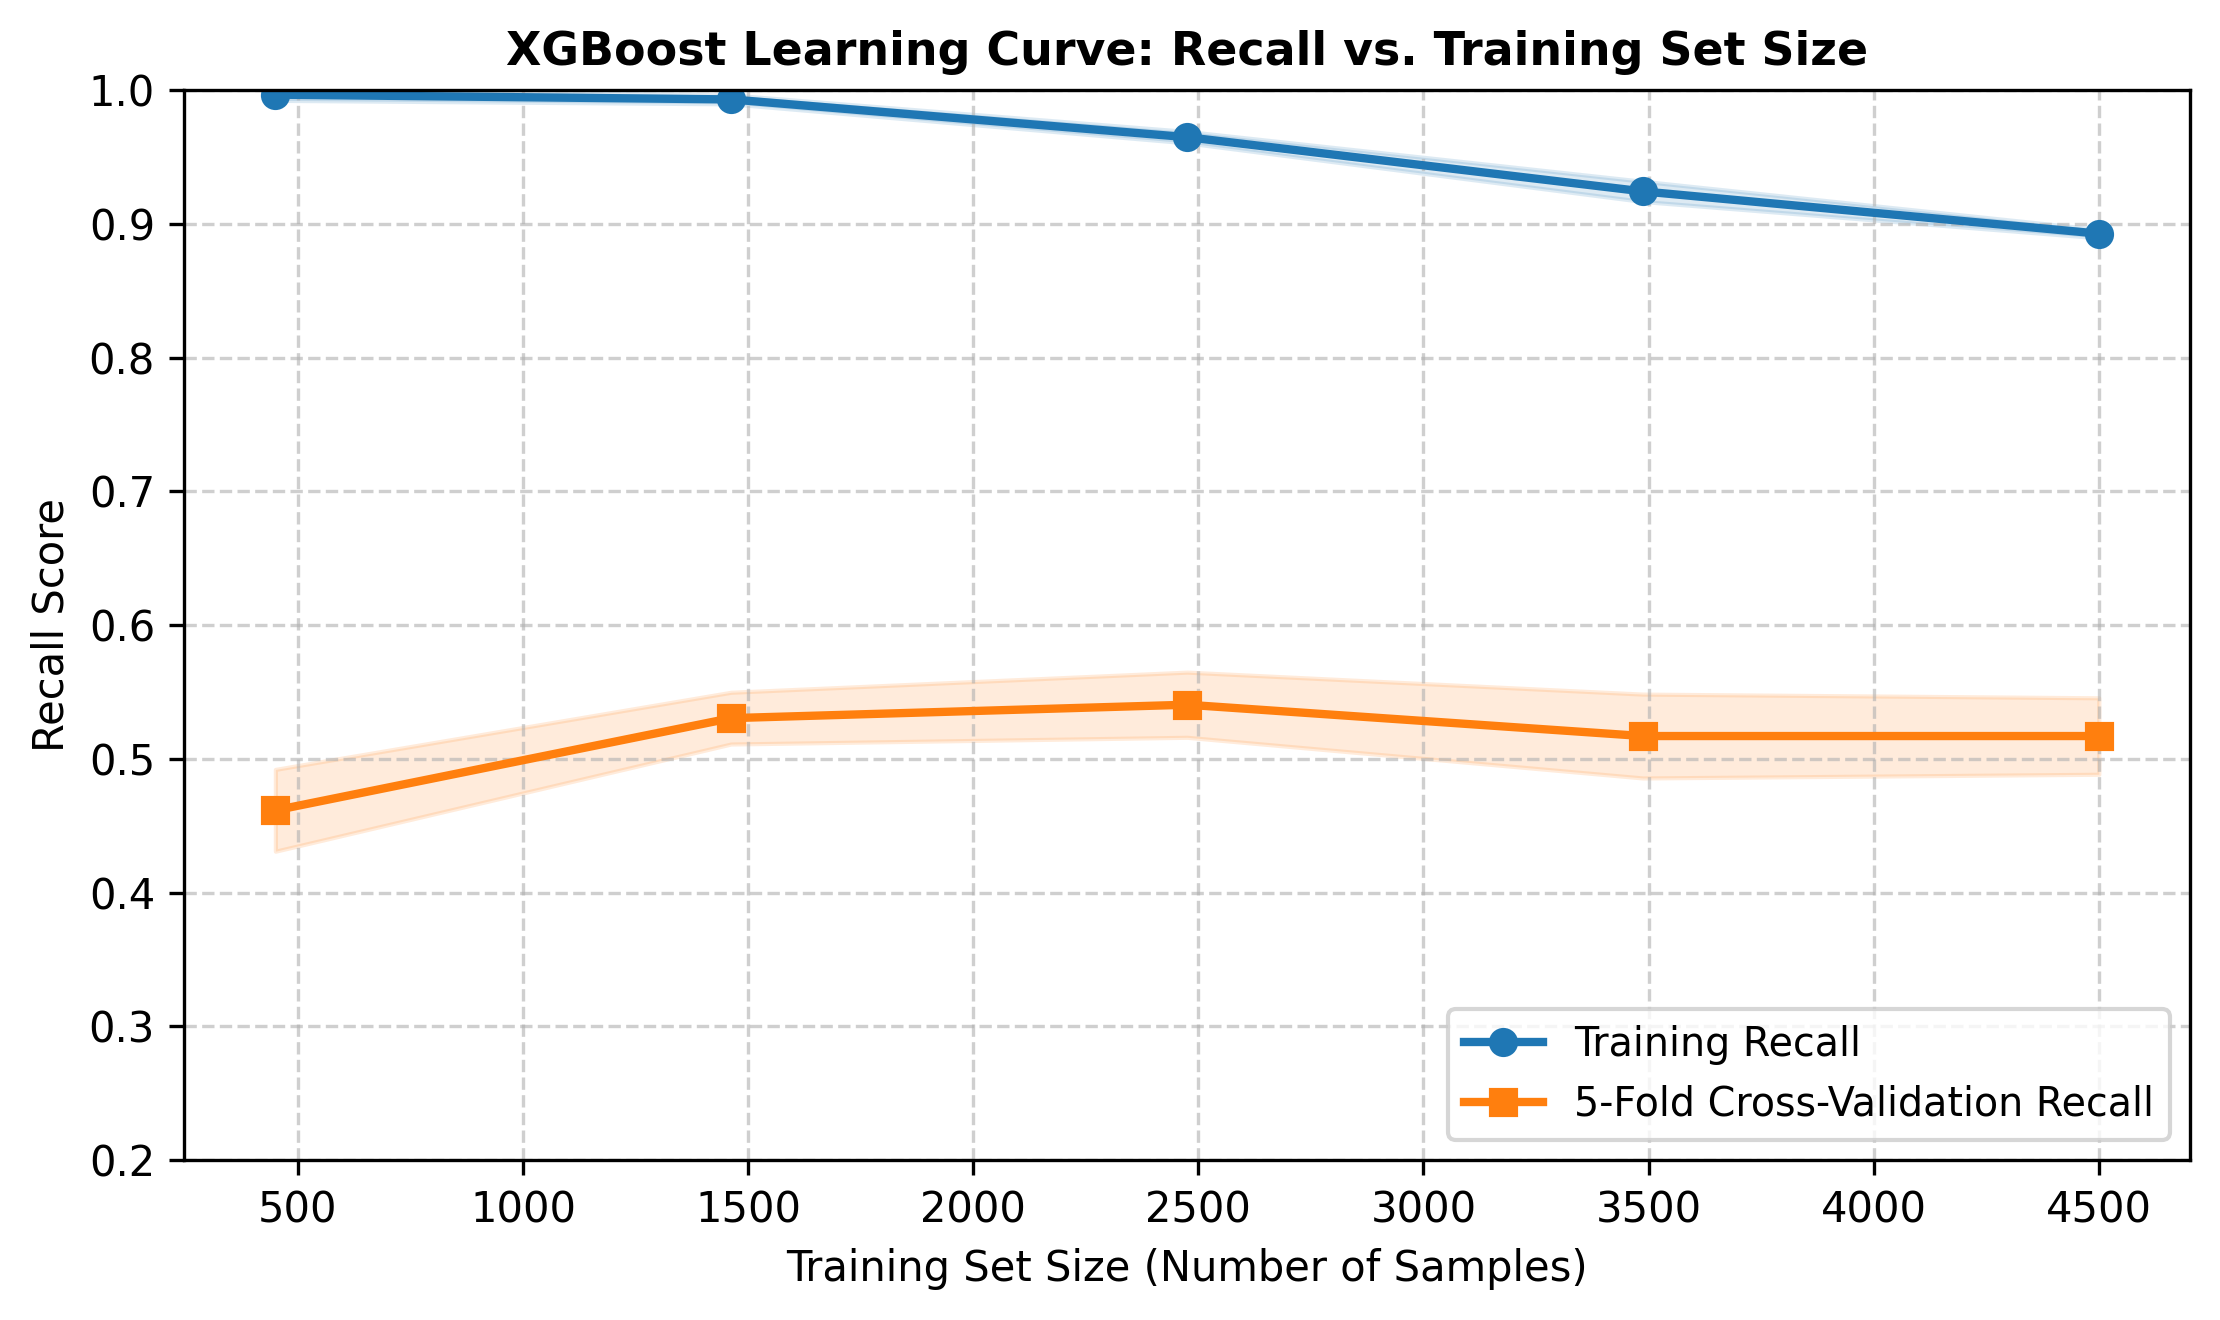

File saved! Check learning_curve.png now.


In [6]:
plt.figure(figsize=(7.5, 4.5), dpi=300)

plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', linewidth=2, label='Training Recall')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

plt.plot(train_sizes, val_mean, 's-', color='#ff7f0e', linewidth=2, label='5-Fold Cross-Validation Recall')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#ff7f0e')

plt.title('XGBoost Learning Curve: Recall vs. Training Set Size', fontsize=11, fontweight='bold')
plt.xlabel('Training Set Size (Number of Samples)', fontsize=10)
plt.ylabel('Recall Score', fontsize=10)
plt.ylim([0.2, 1.0])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=9.5)
plt.tight_layout()

plt.savefig("learning_curve.png", dpi=300, facecolor='white', edgecolor='none', bbox_inches='tight')
plt.show()

print("File saved! Check learning_curve.png now.")